In [1]:
from xaikd import utils, datasets, models, attributors, bases

import numpy as np
from matplotlib import pyplot as plt

In [2]:
DEVICE = utils.get_device()

In [3]:
dataset = datasets.construct("imagenet-butterfly--spurious-threespurious--1.0")

In [4]:
ds_train = dataset.create_subset(train_split=True)

We have 7800 images in classes [321, 322, 323, 324, 325, 326]


Preparing `ImageNetSuperclassWithThreeSpuriousFeatures[[321, 322, 323, 324, 325, 326]]` samples: 100%|████████████████████████████████████████████████| 7800/7800 [00:00<00:00, 3329151.44it/s]


In [5]:
dl_train = datasets.build_dataloader(ds_train, shuffle=False)

In [6]:
MODEL_NAME = 'imagenet-vitb-tv'
LAYER_NAME = 'encoder.layers.11'

In [7]:
model = models.get_trained_model(MODEL_NAME)

utils.modify_last_layer_for_subclasses(model, dataset.selected_classes)
model.to(DEVICE);

In [8]:
arr_act, arr_ctx = attributors.extract_activation_context(
    model=model,
    layer=LAYER_NAME,
    dataset=dataset,
    data_loader=dl_train,
    logit_modifier=attributors.WinningClassEvidence(len(dataset.selected_classes)),
    rng=np.random.default_rng(seed=1),
    device=DEVICE
)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 122/122 [08:10<00:00,  4.02s/it]


encoder.layers.11: output-dims=torch.Size([768, 197, 1])


In [9]:
def build_basis(name):
    
    basis = bases.get_basis(f"{name}--uncentered")

    basis.fit(arr_act, arr_ctx)
    return basis
    
basis_pca = build_basis("pca")
basis_prca = build_basis("prca-sortabs")

In [14]:
def correct_direction(X, U):
    d, _ = U.shape
    projection = X @ U

    prop_positive = (projection > 0).mean(axis=0)
    assert prop_positive.shape == (d,)

    has_more_negative = (prop_positive < 0.5)
    correction_factor = np.ones(d)
    correction_factor[has_more_negative] = -1
    np.testing.assert_equal(np.sum(correction_factor == -1), np.sum(has_more_negative))
    
    corrected_U = U * correction_factor.reshape((1, d))


    return corrected_U

def ano():
    X = arr_act
    U  = correct_direction(arr_act, basis_pca.U)

    projection = X @ U

    prop_positive = (projection > 0).mean(axis=0)
    np.testing.assert_allclose(np.sum(prop_positive < 0.5), 0)
    print("Sanity Check Passed!")
ano()

AssertionError: 
Not equal to tolerance rtol=1e-07, atol=0

Mismatched elements: 1 / 1 (100%)
Max absolute difference: 1
Max relative difference: inf
 x: array(1)
 y: array(0)

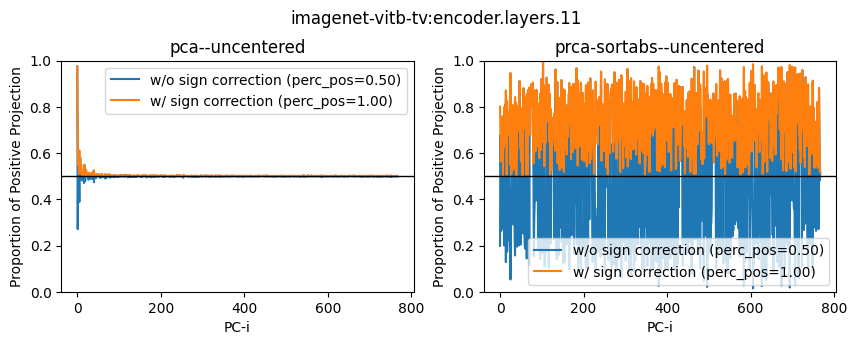

In [15]:
def ano():
    
    plt.figure(figsize=(5*2, 3))
    
    plt.suptitle(f"{MODEL_NAME}:{LAYER_NAME}", y=1.05)
    
    for bix, basis in enumerate([basis_pca, basis_prca]):
        plt.subplot(1, 2, bix +1)
        plt.title(basis)
        before = ((arr_act @ basis.U) > 0).mean(axis=0)
        plt.plot(
          before  , label=f"w/o sign correction (perc_pos={(before > 0.5).mean():.2f})"
        )

        after =  ((arr_act @ correct_direction(arr_act, basis.U)) > 0).mean(axis=0)
        plt.plot(
            after , label=f"w/ sign correction (perc_pos={(after > 0.5).mean():.2f})"
        )
        plt.axhline(0.5, ls="-", lw=1, color="k")
        plt.ylabel("Proportion of Positive Projection")
        plt.xlabel("PC-i")
        plt.ylim([0, 1])
        plt.legend()
ano()